# UNet (Supervised Baseline)
Fully supervised U-Net trained from scratch across multiple label fractions.
No pretraining stage — serves as the baseline for comparison with BT-UNet and SimSiam-UNet.

**Pipeline:**
1. Load KDSB data (cached `.npy` arrays if available)
2. For each label fraction (5%, 10%, 20%, 50%): build a fresh U-Net, train, evaluate, save


## Configuration

In [1]:
# ============================================================
# CONFIGURATION
# ============================================================
# Change paths depending on dataset

DATASET_NAME = "ISIC2018"

DATASET_CONFIGS = {
    "KDSB": {
        "train_path": "datasets/KDSB/train/",
        "val_path":   "datasets/KDSB/val/",       # doesn't exist for KDSB -> HAS_VAL will be False
        "test_path":  "datasets/KDSB/test/",
        "img_dir":    "org",             # subfolder holding images, relative to each split path
        "mask_dir":   "gt",              # subfolder holding masks, relative to each split path
        "mask_name":  lambda img_name: img_name,
    },
    "ISIC2018": {
        "train_path": "datasets/ISIC2018/train/",
        "val_path":   "datasets/ISIC2018/val/",
        "test_path":  "datasets/ISIC2018/test/",
        "img_dir":    "org",
        "mask_dir":   "gt",
        "mask_name":  lambda img_name: os.path.splitext(img_name)[0] + "_segmentation.png",
    },
}

cfg = DATASET_CONFIGS[DATASET_NAME]
TRAIN_PATH   = cfg["train_path"]
VAL_PATH     = cfg["val_path"]
TEST_PATH    = cfg["test_path"]
IMG_DIR      = cfg["img_dir"]
MASK_DIR     = cfg["mask_dir"]
mask_name_fn = cfg["mask_name"]

SAVE_DIR     = "saved_models"
SAVE_NP      = "saved_np"

IMG_HEIGHT   = 256
IMG_WIDTH    = 256
IMG_CHANNELS = 3

# Label fractions to sweep
LABEL_FRACTIONS = [0.05, 0.10, 0.20, 0.5]


val_split  = 0.3
THRESHOLD  = 0.5

# Training
FINETUNE_EPOCHS = 200
FINETUNE_BATCH  = 8
TRAIN_FLG       = True   # False = load saved weights, skip training

# TEST_MODE: set True to smoke-test the full pipeline cheaply
TEST_MODE = False

# ---- K-Fold Cross-Validation ----
USE_KFOLD       = True   # False = skip CV, only run the single train/val/test split below
N_FOLDS         = 5      # number of folds per label fraction
CV_RANDOM_STATE = 42


## Imports

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # must be set BEFORE tensorflow is imported
import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from skimage.io import imread, imshow
from skimage.morphology import label
from skimage.transform import resize
from sklearn.model_selection import KFold

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger, TensorBoard
)
from tensorflow.keras.metrics import Accuracy, Precision, Recall, MeanIoU, MeanAbsoluteError
from tensorflow.keras.losses import binary_crossentropy
from hausdorff import hausdorff_distance

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(SAVE_NP,  exist_ok=True)
os.makedirs("logs/fit", exist_ok=True)

I0000 00:00:1786507805.371496 4116968 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Loading

In [3]:
# ---- Detect whether this dataset ships a dedicated validation split ----
HAS_VAL = os.path.isdir(os.path.join(VAL_PATH, IMG_DIR))
print(f"Validation folder found at {VAL_PATH} — will use it for validation."
      if HAS_VAL else
      "No validation folder found — will fall back to splitting train data (val_split).")

x_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
x_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")

if HAS_VAL:
    x_val_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_val_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
    y_val_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_val_{IMG_HEIGHT}x{IMG_WIDTH}.npy")

required_paths = [x_train_path, y_train_path, x_test_path, y_test_path]
if HAS_VAL:
    required_paths += [x_val_path, y_val_path]

def load_split(split_path):
    """Load and resize one split's images + masks using this dataset's naming convention."""
    ids = next(os.walk(os.path.join(split_path, IMG_DIR)))[2][:]
    X = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, 1),            dtype=np.float32)

    for n, id_ in tqdm(enumerate(ids), total=len(ids)):
        img = imread(os.path.join(split_path, IMG_DIR, id_))[:, :, :IMG_CHANNELS]
        img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
        X[n] = img

        mask = imread(os.path.join(split_path, MASK_DIR, mask_name_fn(id_)))
        mask = np.expand_dims(mask, axis=-1)
        mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH, 1), mode='constant', preserve_range=True)
        Y[n][mask[:, :, 0] / 255 > 0.] = 1.

    return X, Y

if all(os.path.exists(p) for p in required_paths):
    print("Found cached arrays, loading...")
    X_train = np.load(x_train_path)
    Y_train = np.load(y_train_path)
    X_test  = np.load(x_test_path)
    Y_test  = np.load(y_test_path)
    if HAS_VAL:
        X_val = np.load(x_val_path)
        Y_val = np.load(y_val_path)
        print(f"Loaded — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    else:
        X_val, Y_val = None, None
        print(f"Loaded — Train: {X_train.shape}, Test: {X_test.shape}")

else:
    print("No cached arrays found, loading and resizing from disk...")

    X_train, Y_train = load_split(TRAIN_PATH)
    X_test,  Y_test  = load_split(TEST_PATH)
    print(f"Train images: {X_train.shape[0]}, Test images: {X_test.shape[0]}")

    np.save(x_train_path, X_train)
    np.save(y_train_path, Y_train)
    np.save(x_test_path,  X_test)
    np.save(y_test_path,  Y_test)

    if HAS_VAL:
        X_val, Y_val = load_split(VAL_PATH)
        print(f"Val images: {X_val.shape[0]}")
        np.save(x_val_path, X_val)
        np.save(y_val_path, Y_val)
        print(f"Saved — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    else:
        X_val, Y_val = None, None
        print(f"Saved — Train: {X_train.shape}, Test: {X_test.shape}")


Validation folder found at datasets/ISIC2018/val/ — will use it for validation.
Found cached arrays, loading...
Loaded — Train: (2594, 256, 256, 3), Val: (100, 256, 256, 3), Test: (1000, 256, 256, 3)


## U-Net Architecture
Identical to BT-UNet and SimSiam-UNet notebooks.

In [4]:
def double_conv_layer(x, filter_size, size, dropout, batch_norm=False):
    axis = 3
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same')(x)
    if batch_norm:
        conv = BatchNormalization(axis=axis)(conv)
    conv = Activation('relu')(conv)
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same')(conv)
    if batch_norm:
        conv = BatchNormalization(axis=axis)(conv)
    conv = Activation('relu')(conv)
    if dropout > 0:
        conv = Dropout(dropout)(conv)
    shortcut = Conv2D(size, kernel_size=(1, 1), padding='same')(x)
    if batch_norm:
        shortcut = BatchNormalization(axis=axis)(shortcut)
    return add([shortcut, conv])

def encoder(inputs):
    num_filters = [16, 32, 64, 128]
    skip_connections = []
    x = inputs
    for f in num_filters:
        a = double_conv_layer(x, 3, f, 0.1, True)
        skip_connections.append(a)
        x = MaxPooling2D(pool_size=(2, 2))(a)
    return x, skip_connections

def bottleneck(inputs):
    return double_conv_layer(inputs, 3, 256, 0.1, True)

def decoder(inputs, skip_connections):
    num_filters = [128, 64, 32, 16]
    skip_connections = skip_connections[::-1]
    x = inputs
    for i, f in enumerate(num_filters):
        x_up  = UpSampling2D(size=(2, 2), data_format="channels_last")(x)
        x_att = concatenate([x_up, skip_connections[i]], axis=-1)
        x     = double_conv_layer(x_att, 3, f, 0.1, True)
    return x

def output_layer(inputs):
    x = Conv2D(1, kernel_size=(1, 1))(inputs)
    x = BatchNormalization()(x)
    x = Activation('sigmoid')(x)
    return x

def build_unet(name="unet"):
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    s      = layers.Rescaling(1.0 / 255)(inputs)
    x, skips = encoder(s)
    x        = bottleneck(x)
    x        = decoder(x, skips)
    outputs  = output_layer(x)
    return Model(inputs, outputs, name=name)

## Metrics
Identical to BT-UNet and SimSiam-UNet notebooks.

In [5]:
def iou_metric(y_true_in, y_pred_in):
    labels       = label(y_true_in > 0.5)
    y_pred       = label(y_pred_in > 0.5)
    true_objects = len(np.unique(labels))
    pred_objects = len(np.unique(y_pred))
    intersection = np.histogram2d(labels.flatten(), y_pred.flatten(),
                                  bins=(true_objects, pred_objects))[0]
    area_true    = np.expand_dims(np.histogram(labels, bins=true_objects)[0], -1)
    area_pred    = np.expand_dims(np.histogram(y_pred, bins=pred_objects)[0],  0)
    union        = area_true + area_pred - intersection
    intersection = intersection[1:, 1:]
    union        = union[1:, 1:]
    union[union == 0] = 1e-9
    iou = intersection / union

    def precision_at(threshold, iou):
        matches = iou > threshold
        tp = np.sum(np.sum(matches, axis=1) == 1)
        fp = np.sum(np.sum(matches, axis=0) == 0)
        fn = np.sum(np.sum(matches, axis=1) == 0)
        return tp, fp, fn

    prec = []
    for t in np.arange(0.5, 1.0, 0.05):
        tp, fp, fn = precision_at(t, iou)
        p = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        prec.append(p)
    return np.mean(prec)

def iou_metric_batch(y_true_in, y_pred_in):
    return sum(iou_metric(y_true_in[b], y_pred_in[b])
               for b in range(y_true_in.shape[0])) / y_true_in.shape[0]

def dice_coeff(y_true, y_pred):
    smooth       = 1.
    y_true_f     = K.flatten(y_true)
    y_pred_f     = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def haud_dist(y_true, y_pred):
    return hausdorff_distance(np.squeeze(y_true), np.squeeze(y_pred))

def haud_dist_batch(y_true, y_pred):
    if len(y_true.shape) == 2:
        return haud_dist(y_true, y_pred)
    return sum(haud_dist(y_true[b], y_pred[b]) for b in range(y_true.shape[0])) / y_true.shape[0]

def evalResult(gt, pred, num_class=2):
    gt   = np.squeeze(gt)
    pred = np.squeeze(pred)
    acc  = Accuracy();  acc.update_state(gt, pred);  r_acc = acc.result().numpy()
    pr   = Precision(); pr.update_state(gt, pred);   r_pr  = pr.result().numpy()
    rc   = Recall();    rc.update_state(gt, pred);   r_rc  = rc.result().numpy()
    mi   = MeanIoU(num_class); mi.update_state(gt, pred); r_mi = mi.result().numpy()
    dc   = sum(dice_coeff(gt[i], pred[i]).numpy() for i in range(gt.shape[0])) / gt.shape[0]
    hd   = haud_dist_batch(gt, pred)
    miou = iou_metric_batch(gt, pred)
    mae  = MeanAbsoluteError()
    r_mae = mae(gt, pred).numpy()
    print(f"  Acc={r_acc:.4f}  Prec={r_pr:.4f}  Rec={r_rc:.4f}  MeanIoU={r_mi:.4f}  "
          f"Dice={dc:.4f}  HD={hd:.4f}  MyIoU={miou:.4f}  MAE={r_mae:.4f}")
    return dict(Accuracy=r_acc, Precision=r_pr, Recall=r_rc,
                MeanIoU=r_mi, Dice=dc, HD=hd, MyIoU=miou, MAE=r_mae)

## Loss Functions

In [6]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return 0.4 * binary_crossentropy(y_true, y_pred) + 0.6 * dice_loss(y_true, y_pred)

## Training Loop — All Label Fractions
Builds a fresh U-Net from scratch for each fraction. No pretraining.

In [7]:
# Only runs the single train/val/test split when USE_KFOLD is False.
# When USE_KFOLD is True, this is skipped entirely — the K-Fold CV
# section below covers that fraction/model combination instead, so
# nothing is trained twice.
if not USE_KFOLD:
    fractions_to_run = [LABEL_FRACTIONS[0]] if TEST_MODE else LABEL_FRACTIONS
    FT_EPOCHS = 1 if TEST_MODE else FINETUNE_EPOCHS
    FT_BATCH  = 2 if TEST_MODE else FINETUNE_BATCH
    TEST_CAP  = 10

    all_results = []

    for fraction in fractions_to_run:
        pct     = int(fraction * 100)
        keyname = f"{DATASET_NAME}_UNet_{pct}pct"
        print(f"\n{'='*60}")
        print(f"Training: {keyname}  ({pct}% labelled data)")
        print(f"{'='*60}")

        tf.keras.backend.clear_session()

        # ---- Slice labelled subset ----
        n_labelled = int(X_train.shape[0] * fraction)
        if TEST_MODE:
            n_labelled = min(n_labelled, TEST_CAP)
            print(f"[TEST_MODE] capped to {n_labelled} samples, {FT_EPOCHS} epoch")
        X_subset = X_train[:n_labelled]
        Y_subset = Y_train[:n_labelled]

        # ---- Build model from scratch ----
        model = build_unet(name=keyname)

        # ---- Callbacks ----
        cur_date = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        callbacks = [
            ModelCheckpoint(
                os.path.join(SAVE_DIR, f"model_{keyname}.keras"),
                monitor='val_dice_coeff', mode='max', verbose=1, save_best_only=True
            ),
            ReduceLROnPlateau(monitor='val_dice_coeff',mode='max', factor=0.1, patience=10),
            EarlyStopping(monitor='val_dice_coeff',mode='max', verbose=1, patience=20),
            CSVLogger(f"logs/{keyname}_{cur_date}.log"),
            TensorBoard(log_dir=f"logs/fit/{keyname}_{cur_date}", histogram_freq=0),
        ]

        # ---- Compile + Train ----
        model.compile(
            loss=bce_dice_loss,
            optimizer=Adam(),
            metrics=['accuracy', Precision(), MeanIoU(num_classes=2), Recall(),
                     dice_coeff, MeanAbsoluteError()]
        )

        if TRAIN_FLG:
            history = model.fit(
                X_subset, Y_subset,
                validation_split=val_split,
                batch_size=FT_BATCH,
                epochs=FT_EPOCHS,
                callbacks=callbacks
            )
            plt.plot(history.history['loss'],     label='train')
            plt.plot(history.history['val_loss'], label='val')
            plt.title(f"{keyname} — Loss")
            plt.legend()
            plt.grid()
            plt.show()
        else:
            print("Loading saved weights...")
            model.load_weights(os.path.join(SAVE_DIR, f"model_{keyname}.keras"))

        # ---- Evaluate ----
        if HAS_VAL:
            X_tr_split = X_subset
            Y_tr_split = Y_subset
            X_val_eval = X_val
            Y_val_eval = Y_val
        else:
            split_idx  = int(X_subset.shape[0] * (1 - val_split))
            X_tr_split = X_subset[:split_idx]
            Y_tr_split = Y_subset[:split_idx]
            X_val_eval = X_subset[split_idx:]
            Y_val_eval = Y_subset[split_idx:]

        preds_train = (model.predict(X_tr_split, verbose=1) > THRESHOLD).astype(np.float32)
        preds_full  = (model.predict(X_train,    verbose=1) > THRESHOLD).astype(np.float32)
        preds_val   = (model.predict(X_val_eval, verbose=1) > THRESHOLD).astype(np.float32)
        preds_test  = (model.predict(X_test,     verbose=1) > THRESHOLD).astype(np.float32)

        print("\nTRAIN")
        train_m = evalResult(Y_tr_split.astype(np.float32), preds_train)
        print("\nFULL DATASET")
        full_m  = evalResult(Y_train.astype(np.float32),    preds_full)
        print("\nVALIDATION")
        val_m   = evalResult(Y_val_eval.astype(np.float32),  preds_val)
        print("\nTEST")
        test_m  = evalResult(Y_test.astype(np.float32),     preds_test)

        row = {"Dataset": DATASET_NAME, "Model": keyname, "Label Fraction (%)": pct}
        for split_name, metrics in [("Train", train_m), ("Full", full_m),
                                      ("Val", val_m), ("Test", test_m)]:
            for k, v in metrics.items():
                row[f"{split_name} {k}"] = v
        all_results.append(row)

    print("\nAll label fractions complete.")
else:
    all_results = []
    print("USE_KFOLD is True — skipping single-split loop (see K-Fold CV section below).")


USE_KFOLD is True — skipping single-split loop (see K-Fold CV section below).


## Results Table

In [8]:
results_df = pd.DataFrame(all_results)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("\n================ FINAL RESULTS ================\n")
display(results_df)

os.makedirs("results", exist_ok=True)
results_csv_path = os.path.join("results", f"{DATASET_NAME}_baseline_results.csv")
results_df.to_csv(results_csv_path, index=False)
print(f"Saved to {results_csv_path}")


================ FINAL RESULTS ================



""


Saved to results/ISIC2018_baseline_results.csv


## K-Fold Cross-Validation
The single train/val/test split above gives one estimate per label fraction, which can be noisy — especially at 5% and 10% labels, where only a handful of images decide the split. This section reruns training with `N_FOLDS`-fold cross-validation over each labelled subset, so every fraction gets a mean ± std across multiple independent splits instead of a single number.

Each fold builds a fresh U-Net from scratch (via `build_unet`), trains on `N_FOLDS - 1` folds, and evaluates on the held-out fold plus the untouched external test set. Every fold's model is also saved to disk (`model_UNet_{pct}pct_fold{i}.keras`).

**Ensembling**: once all folds for a label fraction are trained, their `N_FOLDS` models are combined into a single ensemble model that averages their predictions. Because each fold saw a different subset of the labelled data, averaging tends to smooth out individual folds' blind spots and gives a small but real accuracy bump over any single fold. The ensemble is saved as `model_UNet_{pct}pct_ensemble.keras` and is what the Qualitative Visualisation section loads (falling back to the single-split model if no ensemble exists).

Set `USE_KFOLD = False` in the configuration cell to skip this whole section — the single train/val/test split section above will run instead (the two sections are mutually exclusive, so nothing gets trained twice).


In [9]:
cv_fractions_to_run = [LABEL_FRACTIONS[0]] if TEST_MODE else LABEL_FRACTIONS
CV_EPOCHS = 1 if TEST_MODE else FINETUNE_EPOCHS
CV_BATCH  = 2 if TEST_MODE else FINETUNE_BATCH
CV_TEST_CAP = 10
RECALL_FLOOR = 0.05  # folds with held-out val recall below this are collapsed/degenerate
                     # and are excluded from the ensemble (still logged in cv_results)

cv_results = []
ensemble_results = []

if USE_KFOLD:
    for fraction in cv_fractions_to_run:
        pct = int(fraction * 100)

        # ---- Slice labelled subset (same logic as the single-split loop) ----
        n_labelled = int(X_train.shape[0] * fraction)
        if TEST_MODE:
            n_labelled = min(n_labelled, CV_TEST_CAP)
        X_subset = X_train[:n_labelled]
        Y_subset = Y_train[:n_labelled]

        n_folds_this = 2 if TEST_MODE else min(N_FOLDS, X_subset.shape[0])
        kf = KFold(n_splits=n_folds_this, shuffle=True, random_state=CV_RANDOM_STATE)

        print(f"\n{'='*60}")
        print(f"K-Fold CV: {pct}% labelled data — {n_folds_this} folds, {X_subset.shape[0]} samples")
        print(f"{'='*60}")

        fold_model_paths = []

        for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_subset)):
            keyname = f"{DATASET_NAME}_UNet_{pct}pct_fold{fold_idx}"
            fold_model_path = os.path.join(SAVE_DIR, f"model_{keyname}.keras")
            print(f"\n--- Fold {fold_idx + 1}/{n_folds_this} ({keyname}) ---")

            X_fold_tr, Y_fold_tr   = X_subset[tr_idx],  Y_subset[tr_idx]
            X_fold_val, Y_fold_val = X_subset[val_idx], Y_subset[val_idx]

            # ---- Build fresh model from scratch ----
            tf.keras.backend.clear_session()
            model = build_unet(name=keyname)
            model.compile(
                loss=bce_dice_loss,
                optimizer=Adam(),
                metrics=['accuracy', Precision(), MeanIoU(num_classes=2), Recall(),
                         dice_coeff, MeanAbsoluteError()]
            )

            cur_date = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
            callbacks = [
                ModelCheckpoint(
                    fold_model_path,
                    monitor='val_dice_coeff', mode='max',verbose=1, save_best_only=True
                ),
                ReduceLROnPlateau(monitor='val_dice_coeff', mode='max',factor=0.1, patience=10),
                EarlyStopping(monitor='val_dice_coeff', mode='max',verbose=1, patience=20,
                               restore_best_weights=True),
                CSVLogger(f"logs/{keyname}_{cur_date}.log"),
            ]

            if TRAIN_FLG:
                model.fit(
                    X_fold_tr, Y_fold_tr,
                    validation_data=(X_fold_val, Y_fold_val),
                    batch_size=CV_BATCH,
                    epochs=CV_EPOCHS,
                    callbacks=callbacks,
                    verbose=1
                )
            else:
                print("Loading saved fold weights...")
                model.load_weights(fold_model_path)

            preds_fold_val = (model.predict(X_fold_val, verbose=0) > THRESHOLD).astype(np.float32)
            preds_test     = (model.predict(X_test,     verbose=0) > THRESHOLD).astype(np.float32)

            print("  Held-out fold validation:")
            fold_val_m = evalResult(Y_fold_val.astype(np.float32), preds_fold_val)
            print("  External test set:")
            test_m = evalResult(Y_test.astype(np.float32), preds_test)

            row = {"Dataset": DATASET_NAME, "Label Fraction (%)": pct, "Fold": fold_idx}
            for split_name, metrics in [("FoldVal", fold_val_m), ("Test", test_m)]:
                for k, v in metrics.items():
                    row[f"{split_name} {k}"] = v
            cv_results.append(row)
            if fold_val_m['Recall'] >= RECALL_FLOOR:
                fold_model_paths.append(fold_model_path)
            else:
                print(f"  [RECALL FLOOR] Fold {fold_idx} excluded from ensemble "
                      f"(held-out val recall {fold_val_m['Recall']:.4f} < {RECALL_FLOOR})")

            # free GPU memory before the next fold
            del model
            tf.keras.backend.clear_session()

        # ---- Ensemble: average the N_FOLDS fold models into one model ----
        if not fold_model_paths:
            print(f"\n[RECALL FLOOR] All folds excluded at {pct}% labelled data "
                  f"(held-out val recall < {RECALL_FLOOR}) — skipping ensemble.")
            continue
        print(f"\nBuilding ensemble of {len(fold_model_paths)} folds for {pct}% labelled data...")
        fold_models = [
            tf.keras.models.load_model(p, compile=False) for p in fold_model_paths
        ]
        ensemble_input   = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
        fold_outputs     = [m(ensemble_input) for m in fold_models]
        averaged_output  = tf.keras.layers.Average()(fold_outputs) if len(fold_outputs) > 1 else fold_outputs[0]
        ensemble_keyname = f"{DATASET_NAME}_UNet_{pct}pct_ensemble"
        ensemble_model   = tf.keras.Model(ensemble_input, averaged_output, name=ensemble_keyname)

        ensemble_path = os.path.join(SAVE_DIR, f"model_{ensemble_keyname}.keras")
        ensemble_model.save(ensemble_path)
        print(f"Saved ensemble to {ensemble_path}")

        preds_ensemble_test = (ensemble_model.predict(X_test, verbose=0) > THRESHOLD).astype(np.float32)
        print("  Ensemble — external test set:")
        ensemble_test_m = evalResult(Y_test.astype(np.float32), preds_ensemble_test)

        erow = {"Dataset": DATASET_NAME, "Label Fraction (%)": pct, "Folds Combined": len(fold_model_paths)}
        for k, v in ensemble_test_m.items():
            erow[f"Test {k}"] = v
        ensemble_results.append(erow)

        del fold_models, ensemble_model
        tf.keras.backend.clear_session()

    print("\nK-fold cross-validation and ensembling complete.")
else:
    print("USE_KFOLD is False — skipping cross-validation and ensembling (single-split results are in the section above).")



K-Fold CV: 5% labelled data — 5 folds, 129 samples

--- Fold 1/5 (ISIC2018_UNet_5pct_fold0) ---


I0000 00:00:1786507807.787172 4116968 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20543 MB memory:  -> device: 0, name: Quadro RTX 6000, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch 1/200


I0000 00:00:1786507818.461631 4117409 service.cc:153] XLA service 0x78d2080d0020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786507818.461664 4117409 service.cc:161]   StreamExecutor [0]: Quadro RTX 6000, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786507818.879500 4117409 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786507820.652379 4117409 cuda_dnn.cc:461] Loaded cuDNN version 92400
E0000 00:00:1786507825.549925 4117409 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786507827.916955 4117409 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:17865078

 3/13 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6549 - dice_coeff: 0.3013 - loss: 0.6952 - mean_absolute_error: 0.4528 - mean_io_u: 0.4159 - precision: 0.2675 - recall: 0.5665 

...

  Held-out fold validation:
  Acc=0.9491  Prec=0.8787  Rec=0.9020  MeanIoU=0.8690  Dice=0.8439  HD=5.2017  MyIoU=0.5246  MAE=0.0509
  External test set:
  Acc=0.8783  Prec=0.7758  Rec=0.8279  MeanIoU=0.7534  Dice=0.7986  HD=6.3738  MyIoU=0.3894  MAE=0.1217

Building ensemble of 5 folds for 10% labelled data...
Saved ensemble to saved_models/model_ISIC2018_UNet_10pct_ensemble.keras
  Ensemble — external test set:
  Acc=0.8919  Prec=0.8218  Rec=0.8104  MeanIoU=0.7735  Dice=0.8128  HD=5.8624  MyIoU=0.4974  MAE=0.1081

K-Fold CV: 20% labelled data — 5 folds, 518 samples

--- Fold 1/5 (ISIC2018_UNet_20pct_fold0) ---
Epoch 1/200
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7406 - dice_coeff: 0.4300 - loss: 0.5789 - mean_absolute_error: 0.4095 - mean_io_u: 0.3783 - precision: 0.4828 - recall: 0.7080

E0000 00:00:1786509435.592671 4117411 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786509436.775667 4117411 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786509440.150921 4117411 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.7416 - dice_coeff: 0.4306 - loss: 0.5782 - mean_absolute_error: 0.4090 - mean_io_u: 0.3784 - precision: 0.4840 - recall: 0.7092
Epoch 1: val_dice_coeff improved from None to 0.27281, saving model to saved_models/model_ISIC2018_UNet_20pct_fold0.keras

Epoch 1: finished saving model to saved_models/model_ISIC2018_UNet_20pct_fold0.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 58s 664ms/step - accuracy: 0.7890 - dice_coeff: 0.4566 - loss: 0.5435 - mean_absolute_error: 0.3870 - mean_io_u: 0.3789 - precision: 0.5456 - recall: 0.7702 - val_accuracy: 0.7795 - val_dice_coeff: 0.2728 - val_loss: 0.6672 - val_mean_absolute_error: 0.4277 - val_mean_io_u: 0.3897 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/200
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8373 - dice_coeff: 0.4725 - loss: 0.5120 - mean_absolute_error: 0.3601 - mean_io_u: 0.3877 - precision: 0.6022 - recall: 0.8266
Epoch 2: val_dice_coeff did n

E0000 00:00:1786511781.918703 4117409 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786511782.768616 4117409 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786511783.753713 4117409 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.7828 - dice_coeff: 0.4430 - loss: 0.5485 - mean_absolute_error: 0.3853 - mean_io_u: 0.3878 - precision: 0.5180 - recall: 0.7888
Epoch 1: val_dice_coeff improved from None to 0.30366, saving model to saved_models/model_ISIC2018_UNet_50pct_fold0.keras

Epoch 1: finished saving model to saved_models/model_ISIC2018_UNet_50pct_fold0.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 63s 303ms/step - accuracy: 0.8379 - dice_coeff: 0.4857 - loss: 0.5028 - mean_absolute_error: 0.3582 - mean_io_u: 0.3814 - precision: 0.6191 - recall: 0.8230 - val_accuracy: 0.7574 - val_dice_coeff: 0.3037 - val_loss: 0.6590 - val_mean_absolute_error: 0.4441 - val_mean_io_u: 0.3787 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8837 - dice_coeff: 0.5175 - loss: 0.4600 - mean_absolute_error: 0.3205 - mean_io_u: 0.3852 - precision: 0.7009 - recall: 0.8613
Epoch 2: val_dice_coeff

Per-fold results:


,Dataset,Label Fraction (%),Fold,FoldVal Accuracy,FoldVal Precision,FoldVal Recall,FoldVal MeanIoU,FoldVal Dice,FoldVal HD,FoldVal MyIoU,FoldVal MAE,Test Accuracy,Test Precision,Test Recall,Test MeanIoU,Test Dice,Test HD,Test MyIoU,Test MAE
0,ISIC2018,5,0,0.4273,0.2980,0.9669,0.2709,0.4751,12.5662,0.0142,0.5727,0.5277,0.3754,0.8985,0.3584,0.5284,12.4030,0.0277,0.4723
1,ISIC2018,5,1,0.6335,0.0000,0.0000,0.3168,0.0001,11.9121,0.0000,0.3665,0.7042,0.0000,0.0000,0.3521,0.0001,11.3797,0.0000,0.2958
2,ISIC2018,5,2,0.9004,0.7108,0.5258,0.6627,0.6290,5.5935,0.0986,0.0996,0.7864,0.6681,0.5523,0.5890,0.5765,8.2765,0.0994,0.2136
3,ISIC2018,5,3,0.7766,0.9352,0.0009,0.3888,0.0009,10.3304,0.0000,0.2234,0.7162,0.8557,0.0490,0.3803,0.0627,10.9238,0.0037,0.2838
4,ISIC2018,5,4,0.8049,0.0000,0.0000,0.4025,0.0002,10.0058,0.0000,0.1951,0.7042,0.0000,0.0000,0.3521,0.0001,11.3797,0.0000,0.2958
5,ISIC2018,10,0,0.9338,0.8407,0.8870,0.8379,0.8046,5.6485,0.5354,0.0662,0.8948,0.8282,0.8131,0.7786,0.8136,5.8908,0.4768,0.1052
6,ISIC2018,10,1,0.9402,0.8458,0.8511,0.8325,0.8027,5.1577,0.5173,0.0598,0.8813,0.7986,0.8009,0.7554,0.7972,6.2408,0.4333,0.1187
7,ISIC2018,10,2,0.9297,0.9190,0.8592,0.8506,0.8496,5.7293,0.4915,0.0703,0.8869,0.8193,0.7926,0.7635,0.8051,6.1595,0.4346,0.1131
8,ISIC2018,10,3,0.9529,0.8807,0.8705,0.8611,0.8307,4.8773,0.4763,0.0471,0.8828,0.8196,0.7744,0.7548,0.7945,6.1497,0.4327,0.1172
9,ISIC2018,10,4,0.9491,0.8787,0.9020,0.8690,0.8439,5.2017,0.5246,0.0509,0.8783,0.7758,0.8279,0.7534,0.7986,6.3738,0.3894,0.1217



Mean +/- std across folds:


FoldVal Accuracy        FoldVal Precision         \
                                        mean    std              mean    std   
Dataset  Label Fraction (%)                                                    
ISIC2018 5                            0.7086 0.1840            0.3888 0.4222   
         10                           0.9411 0.0098            0.8730 0.0316   
         20                           0.9425 0.0050            0.9143 0.0145   
         50                           0.9464 0.0037            0.9100 0.0083   

                            FoldVal Recall        FoldVal MeanIoU         \
                                      mean    std            mean    std   
Dataset  Label Fraction (%)                                                
ISIC2018 5                          0.2987 0.4374          0.4083 0.1520   
         10                         0.8740 0.0207          0.8502 0.0153   
         20                         0.8371 0.0225          0.8519 0.0084   
         50                         0.8593 0.0135          0.8623 0.0084   

                            FoldVal Dice        FoldVal HD         \
                                    mean    std       mean    std   
Dataset  Label Fraction (%)                                         
ISIC2018 5                        0.2211 0.3070    10.0816 2.7265   
         10                       0.8263 0.0218     5.3229 0.3577   
         20                       0.8570 0.0140     5.0353 0.2147   
         50                       0.8683 0.0109     4.9886 0.1129   

                            FoldVal MyIoU        FoldVal MAE         \
                                     mean    std        mean    std   
Dataset  Label Fraction (%)                                           
ISIC2018 5                         0.0226 0.0430      0.2914 0.1840   
         10                        0.5090 0.0244      0.0589 0.0098   
         20                        0.5903 0.0161      0.0575 0.0050   
         50                        0.6038 0.0186      0.0536 0.0037   

                            Test Accuracy        Test Precision         \
                                     mean    std           mean    std   
Dataset  Label Fraction (%)                                              
ISIC2018 5                         0.6877 0.0958         0.3798 0.3867   
         10                        0.8848 0.0064         0.8083 0.0212   
         20                        0.9037 0.0012         0.8630 0.0090   
         50                        0.9111 0.0030         0.8532 0.0065   

                            Test Recall        Test MeanIoU        Test Dice  \
                                   mean    std         mean    std      mean   
Dataset  Label Fraction (%)                                                    
ISIC2018 5                       0.2999 0.4077       0.4064 0.1028    0.2336   
         10                      0.8018 0.0203       0.7612 0.0105    0.8018   
         20                      0.8018 0.0086       0.7924 0.0019    0.8351   
         50                      0.8450 0.0058       0.8096 0.0055    0.8496   

                                   Test HD        Test MyIoU        Test MAE  \
                               std    mean    std       mean    std     mean   
Dataset  Label Fraction (%)                                                    
ISIC2018 5                  0.2927 10.8725 1.5491     0.0262 0.0426   0.3123   
         10                 0.0077  6.1629 0.1766     0.4334 0.0309   0.1152   
         20                 0.0038  5.8822 0.0759     0.4960 0.0218   0.0963   
         50                 0.0039  5.7895 0.0517     0.5040 0.0176   0.0889   

                                    
                               std  
Dataset  Label Fraction (%)         
ISIC2018 5                  0.0958  
         10                 0.0064  
         20                 0.0012  
         50                 0.0030

Saved to results/ISIC2018_baseline_cv_results.csv and results/ISIC2018_baseline_cv_summary.csv


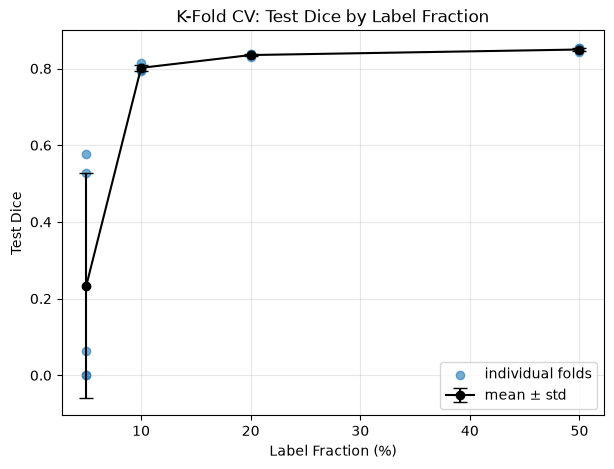


Ensemble results (one row per label fraction, averaged over its fold models):


,Dataset,Label Fraction (%),Folds Combined,Test Accuracy,Test Precision,Test Recall,Test MeanIoU,Test Dice,Test HD,Test MyIoU,Test MAE
0,ISIC2018,5,2,0.7414,0.5506,0.6845,0.5574,0.6116,9.1020,0.1089,0.2586
1,ISIC2018,10,5,0.8919,0.8218,0.8104,0.7735,0.8128,5.8624,0.4974,0.1081
2,ISIC2018,20,5,0.9101,0.8805,0.8054,0.8040,0.8476,5.5464,0.5606,0.0899
3,ISIC2018,50,5,0.9177,0.8692,0.8498,0.8218,0.8603,5.4445,0.5774,0.0823


Saved to results/ISIC2018_baseline_ensemble_results.csv

Ensemble vs. average single fold:


,Ensemble Test Dice,Avg Single-Fold Test Dice
Label Fraction (%),,
5,0.6116,0.2336
10,0.8128,0.8018
20,0.8476,0.8351
50,0.8603,0.8496


In [10]:
if USE_KFOLD and cv_results:
    cv_df = pd.DataFrame(cv_results)
    print("Per-fold results:")
    display(cv_df)

    # Mean +/- std across folds, per label fraction
    metric_cols = [c for c in cv_df.columns if c not in ("Dataset", "Label Fraction (%)", "Fold")]
    group_cols = [c for c in ("Dataset", "Label Fraction (%)") if c in cv_df.columns]
    cv_summary = cv_df.groupby(group_cols)[metric_cols].agg(['mean', 'std'])
    print("\nMean +/- std across folds:")
    display(cv_summary)

    os.makedirs("results", exist_ok=True)
    cv_df.to_csv(os.path.join("results", f"{DATASET_NAME}_baseline_cv_results.csv"), index=False)
    cv_summary.to_csv(os.path.join("results", f"{DATASET_NAME}_baseline_cv_summary.csv"))
    print(f"Saved to results/{DATASET_NAME}_baseline_cv_results.csv and results/{DATASET_NAME}_baseline_cv_summary.csv")

    # Sanity-check plot: Test Dice across folds per label fraction
    fractions_sorted = sorted(cv_df["Label Fraction (%)"].unique())
    plt.figure(figsize=(7, 5))
    for i, pct in enumerate(fractions_sorted):
        sub = cv_df[cv_df["Label Fraction (%)"] == pct]
        plt.scatter([pct] * len(sub), sub["Test Dice"], alpha=0.6, color='tab:blue',
                    label="individual folds" if i == 0 else None)
    means = cv_df.groupby("Label Fraction (%)")["Test Dice"].mean().loc[fractions_sorted]
    stds  = cv_df.groupby("Label Fraction (%)")["Test Dice"].std().loc[fractions_sorted]
    plt.errorbar(fractions_sorted, means.values, yerr=stds.values, fmt='o-',
                 color='black', capsize=5, label="mean ± std")
    plt.xlabel("Label Fraction (%)")
    plt.ylabel("Test Dice")
    plt.title("K-Fold CV: Test Dice by Label Fraction")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    cv_df = pd.DataFrame()

if USE_KFOLD and ensemble_results:
    ensemble_df = pd.DataFrame(ensemble_results)
    print("\nEnsemble results (one row per label fraction, averaged over its fold models):")
    display(ensemble_df)

    os.makedirs("results", exist_ok=True)
    ensemble_df.to_csv(os.path.join("results", f"{DATASET_NAME}_baseline_ensemble_results.csv"), index=False)
    print(f"Saved to results/{DATASET_NAME}_baseline_ensemble_results.csv")

    # Compare: single best fold's Test Dice (mean across folds) vs. the ensemble's Test Dice
    if not cv_df.empty:
        fold_mean_dice = cv_df.groupby("Label Fraction (%)")["Test Dice"].mean()
        compare_df = ensemble_df[["Label Fraction (%)", "Test Dice"]].rename(
            columns={"Test Dice": "Ensemble Test Dice"}
        ).set_index("Label Fraction (%)")
        compare_df["Avg Single-Fold Test Dice"] = fold_mean_dice
        print("\nEnsemble vs. average single fold:")
        display(compare_df)
else:
    ensemble_df = pd.DataFrame()


## Qualitative Visualisation

Loaded: saved_models/model_ISIC2018_UNet_50pct_ensemble.keras


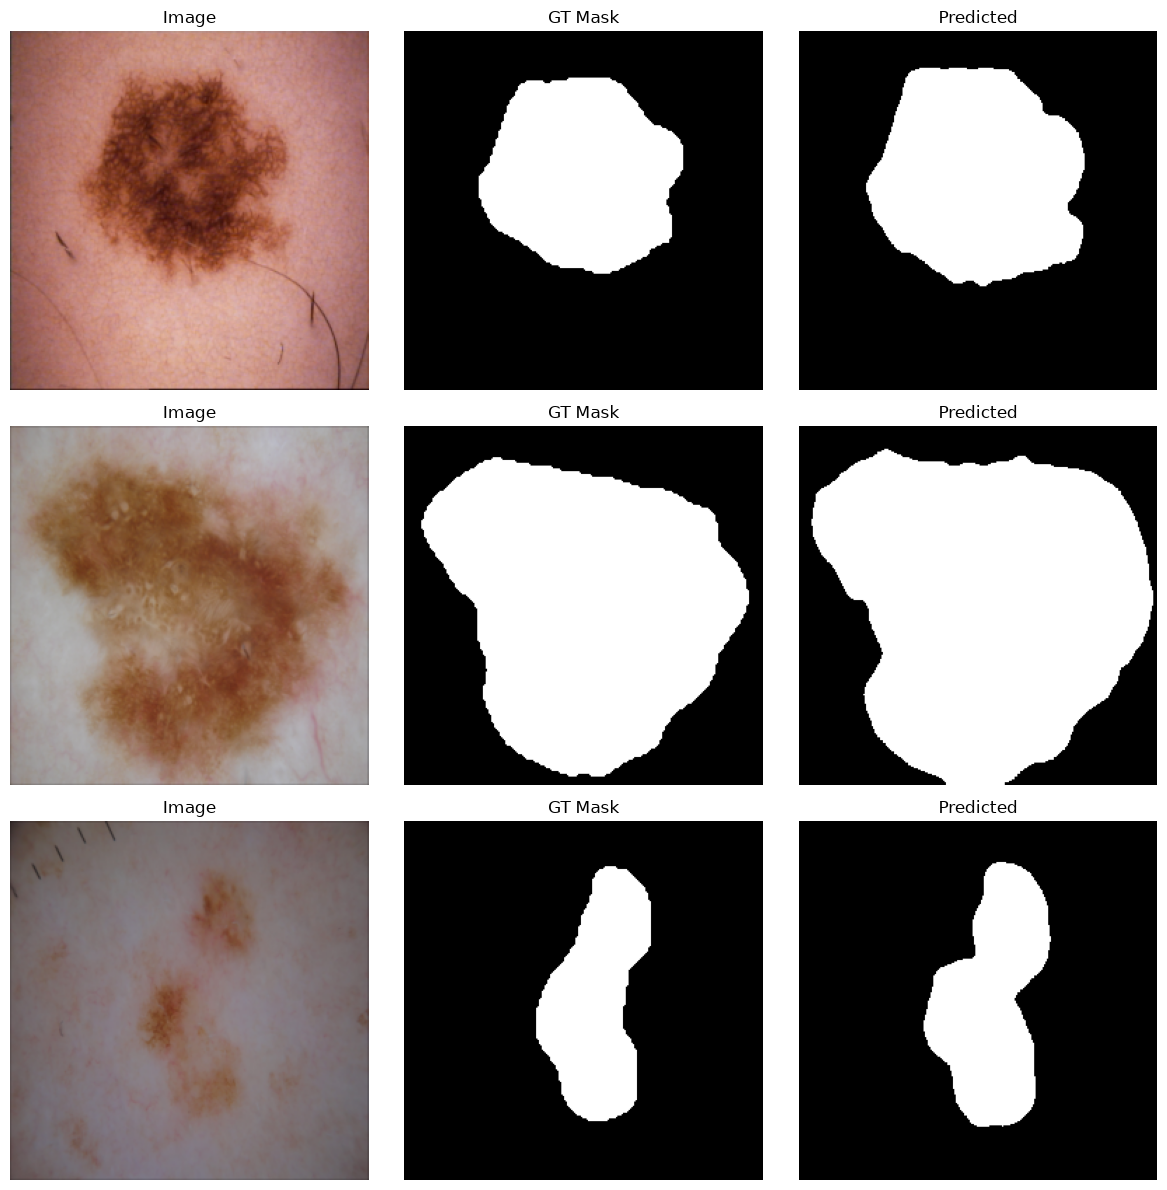

In [11]:
# Reload the best available model (50% fraction) for visualisation.
# Prefers the K-fold ensemble if one was built; falls back to the single-split
# model (e.g. if USE_KFOLD was False).
ensemble_path_vis = os.path.join(SAVE_DIR, f"model_{DATASET_NAME}_UNet_50pct_ensemble.keras")
single_path_vis   = os.path.join(SAVE_DIR, f"model_{DATASET_NAME}_UNet_50pct.keras")
model_path_vis    = ensemble_path_vis if os.path.exists(ensemble_path_vis) else single_path_vis

best_model = tf.keras.models.load_model(model_path_vis, compile=False)
print(f"Loaded: {model_path_vis}")
preds_test_vis = (best_model.predict(X_test, verbose=0) > THRESHOLD).astype(np.float32)

sample_idx = [0, 1, 2]
fig, axes  = plt.subplots(len(sample_idx), 3, figsize=(12, 4 * len(sample_idx)))
for row, ix in enumerate(sample_idx):
    axes[row, 0].imshow(X_test[ix].astype('uint8'));               axes[row, 0].set_title('Image');     axes[row, 0].axis('off')
    axes[row, 1].imshow(np.squeeze(Y_test[ix]), cmap='gray');      axes[row, 1].set_title('GT Mask');   axes[row, 1].axis('off')
    axes[row, 2].imshow(np.squeeze(preds_test_vis[ix]), cmap='gray'); axes[row, 2].set_title('Predicted'); axes[row, 2].axis('off')
plt.tight_layout()
plt.show()
